<a href="https://colab.research.google.com/github/hariharan-075/ML/blob/main/2420080075_week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

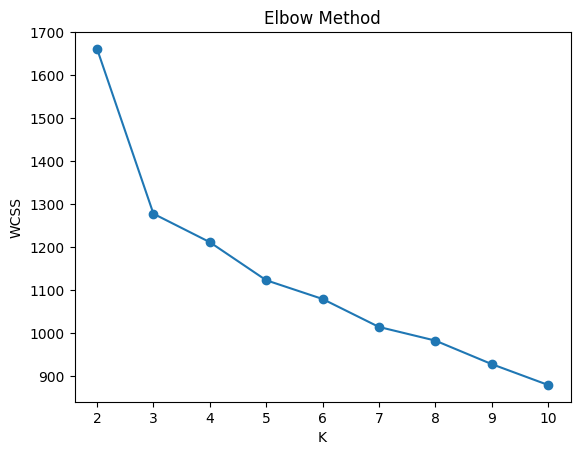

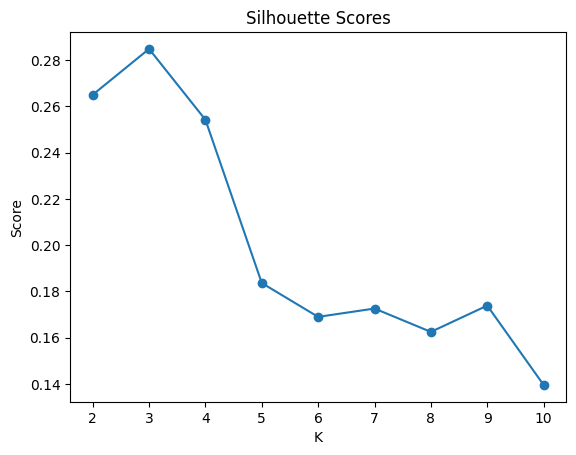

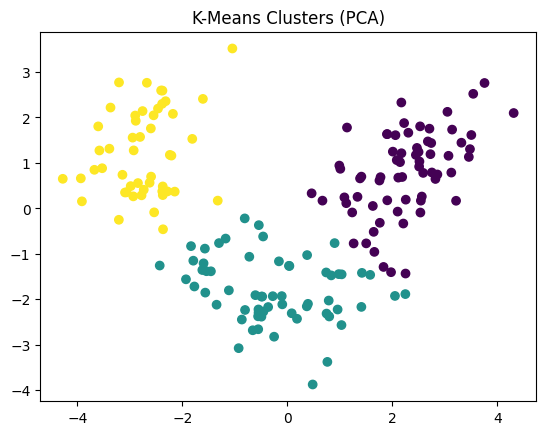

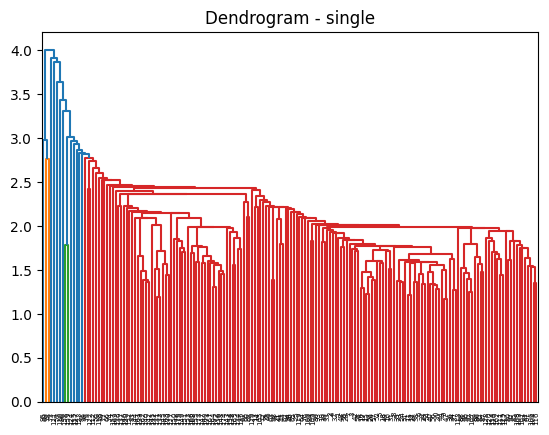

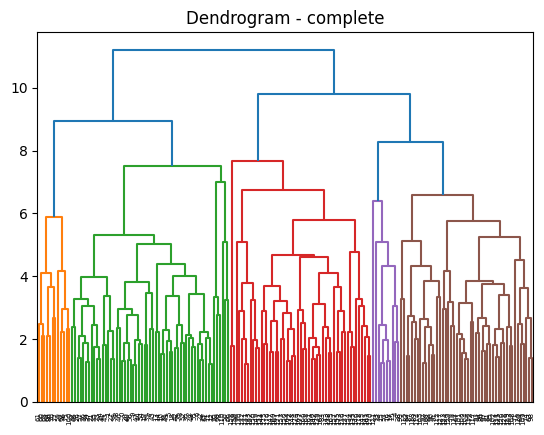

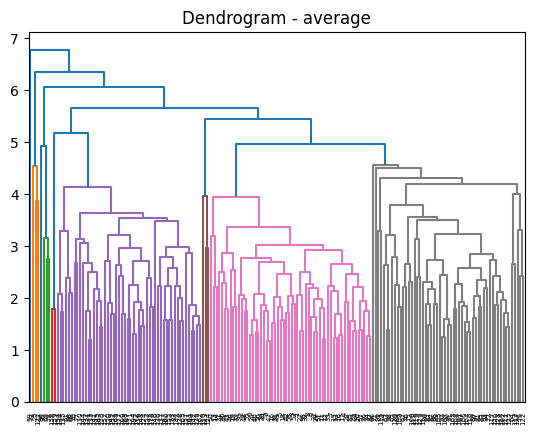

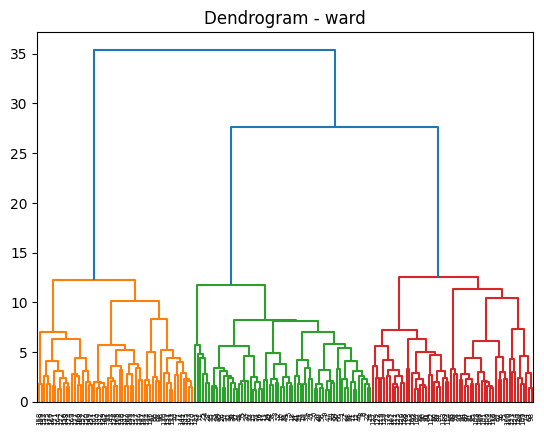

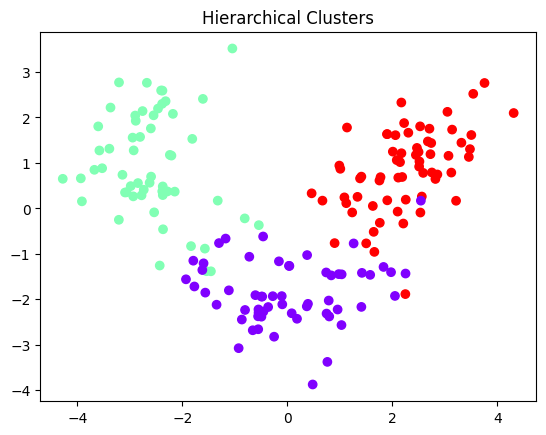

K-Means Time: 0.0065076351165771484
Hierarchical Time: 0.006782054901123047


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

# -------- Load Dataset (Customer-like dataset) --------
data = load_wine()
X = data.data

# -------- Preprocess & Scale --------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------- K-Means Clustering --------
wcss = []
sil_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Elbow curve
plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

# Silhouette scores
plt.plot(range(2,11), sil_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

# PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')
plt.title("K-Means Clusters (PCA)")
plt.show()

# -------- Hierarchical Clustering --------
methods = ['single','complete','average','ward']

for m in methods:
    Z = linkage(X_scaled, method=m)
    plt.title("Dendrogram - "+m)
    dendrogram(Z)
    plt.show()

# Agglomerative clustering
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_h = agg.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_h, cmap='rainbow')
plt.title("Hierarchical Clusters")
plt.show()

# -------- Time Comparison --------
start = time.time()
KMeans(n_clusters=3).fit(X_scaled)
kmeans_time = time.time() - start

start = time.time()
AgglomerativeClustering(n_clusters=3).fit(X_scaled)
hier_time = time.time() - start

print("K-Means Time:", kmeans_time)
print("Hierarchical Time:", hier_time)

KMeans Silhouette: 0.11815695020981745
DBSCAN Silhouette: -0.23321520415114058
GMM Silhouette: 0.12622317200983077
KMeans DB Index: 2.091686471805887
GMM DB Index: 1.8956338594820934


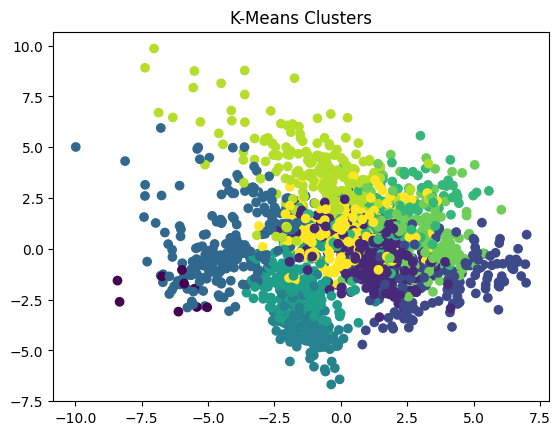

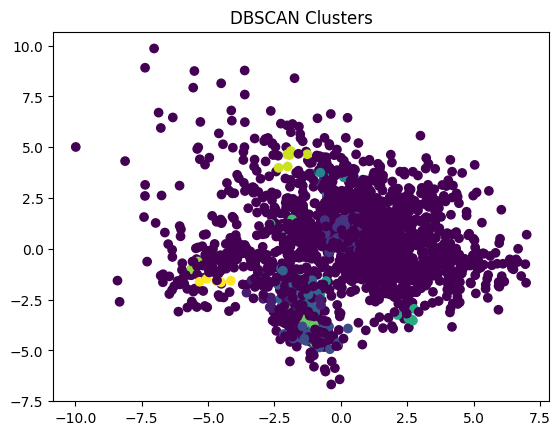

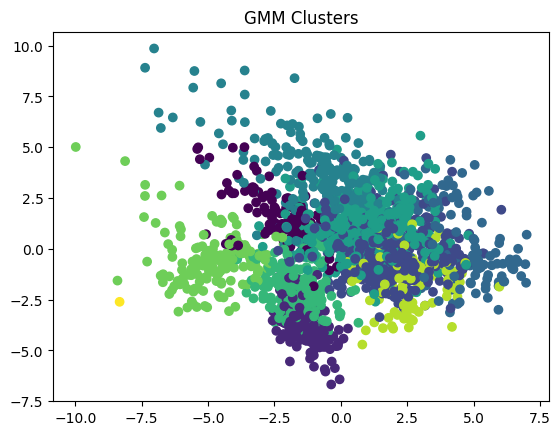

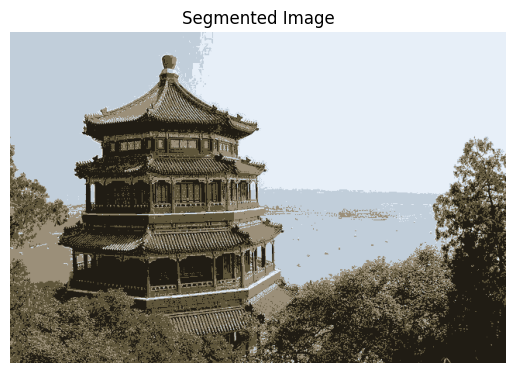

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Load dataset
digits = load_digits()
X = digits.data

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------- Dimensionality Reduction --------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -------- K-Means --------
kmeans = KMeans(n_clusters=10)
labels_k = kmeans.fit_predict(X_scaled)

# -------- DBSCAN --------
dbscan = DBSCAN(eps=3, min_samples=5)
labels_d = dbscan.fit_predict(X_scaled)

# -------- Gaussian Mixture Model --------
gmm = GaussianMixture(n_components=10)
labels_g = gmm.fit_predict(X_scaled)

# -------- Cluster Validation --------
print("KMeans Silhouette:", silhouette_score(X_scaled, labels_k))
print("DBSCAN Silhouette:", silhouette_score(X_scaled, labels_d))
print("GMM Silhouette:", silhouette_score(X_scaled, labels_g))

print("KMeans DB Index:", davies_bouldin_score(X_scaled, labels_k))
print("GMM DB Index:", davies_bouldin_score(X_scaled, labels_g))

# -------- Visualization --------
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_k)
plt.title("K-Means Clusters")
plt.show()

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_d)
plt.title("DBSCAN Clusters")
plt.show()

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_g)
plt.title("GMM Clusters")
plt.show()

# -------- Image Segmentation --------
from sklearn.datasets import load_sample_image
from sklearn.cluster import KMeans

image = load_sample_image("china.jpg")
X_img = np.reshape(image, (-1,3))

kmeans = KMeans(n_clusters=5)
labels = kmeans.fit_predict(X_img)

segmented = kmeans.cluster_centers_[labels]
segmented = segmented.reshape(image.shape)

plt.imshow(segmented.astype('uint8'))
plt.title("Segmented Image")
plt.axis("off")
plt.show()